# Pokémon Pack Value Analysis

## Overview
This project analyzes the expected value of opening Pokémon card packs using real-world card pricing data and Monte Carlo simulation.

The goal is to answer:
- Is opening Pokémon packs profitable?
- What drives the value of a pack?
- Why does it *feel* profitable despite losses?

## Data Sources

- Pokémon card dataset (card attributes, rarity)
- Pokémon trading card marketplace data (pricing)

Pricing data was used to estimate the economic value of cards by rarity tier.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [18]:
cards_df = pd.read_csv("../data/pokemon-tcg-data-master 1999-2023.csv")

price_df = pd.read_csv(
    "../data/pokemon_cards.csv",
    encoding="latin1"
)

## Data Cleaning

The pricing dataset required cleaning due to:
- Currency symbols (£)
- Encoding inconsistencies
- String-based numeric values

In [19]:
price_df = price_df.rename(columns={"Price £": "price"})

price_df["price"] = (
    price_df["price"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .str.replace(",", "", regex=False)
)

price_df["price"] = pd.to_numeric(price_df["price"], errors="coerce")

## Price Distribution

Card prices are highly skewed, with most cards having low value and a small number of high-value outliers.

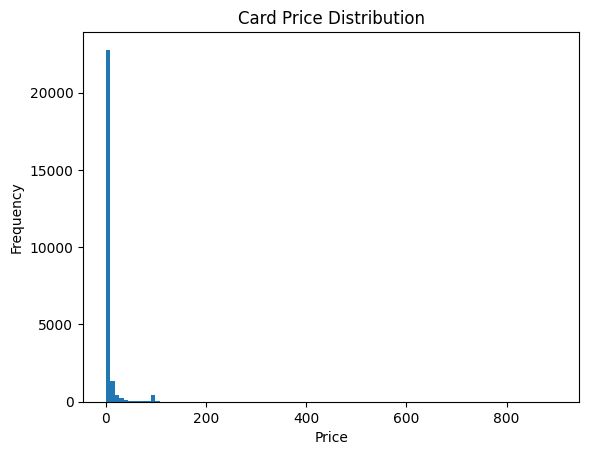

In [21]:
plt.hist(price_df["price"].dropna(), bins=100)
plt.title("Card Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Feature Engineering

Cards were grouped into rarity tiers based on price ranges to align economic value with gameplay rarity.

In [24]:
def map_price_to_rarity(price):
    if price < 0.3:
        return "Common"
    elif price < 1:
        return "Uncommon"
    elif price < 3:
        return "Rare"
    elif price < 10:
        return "Holo"
    elif price < 50:
        return "Ultra Rare"
    else:
        return "Secret Rare"

price_df["rarity_grouped"] = price_df["price"].apply(map_price_to_rarity)

In [25]:
price_df["rarity_grouped"].value_counts()

rarity_grouped
Uncommon       7126
Common         6739
Rare           5602
Holo           3651
Ultra Rare     1736
Secret Rare     744
Name: count, dtype: int64

In [26]:
price_by_rarity = price_df.groupby("rarity_grouped")["price"].mean()

card_values = price_by_rarity.to_dict()

card_values

{'Common': 0.1988143641489835,
 'Holo': 5.658811284579567,
 'Rare': 1.9259246697608,
 'Secret Rare': 108.27162634408602,
 'Ultra Rare': 20.203358294930876,
 'Uncommon': 0.573456357002526}

## Modeling Approach

Pack composition was simulated using:
- Real-world pricing data (value)
- Known pack rarity probabilities (distribution)

This avoids bias from marketplace listings while preserving realistic value estimates.

In [28]:
rarity_probs = {
    "Common": 0.6,
    "Uncommon": 0.25,
    "Rare": 0.1,
    "Holo": 0.04,
    "Ultra Rare": 0.009,
    "Secret Rare": 0.001
}

In [30]:
COMMON_VALUE = 0.10
UNCOMMON_VALUE = 0.25
REVERSE_HOLO_VALUE = 0.50
PACK_COST = 5

def simulate_pack_value():
    total = 0
    
    total += 6 * COMMON_VALUE
    total += 3 * UNCOMMON_VALUE
    total += REVERSE_HOLO_VALUE
    
    rarity = np.random.choice(
        list(rarity_probs.keys()),
        p=list(rarity_probs.values())
    )
    
    total += card_values.get(rarity, 0)
    
    return total

In [31]:
def expected_value(n_sim=10000):
    return np.mean([simulate_pack_value() for _ in range(n_sim)])

ev = expected_value()

print("EV:", round(ev, 2))
print("Profit per pack:", round(ev - PACK_COST, 2))

EV: 2.85
Profit per pack: -2.15


## Results

The expected value of a pack is below the purchase price, indicating that opening packs is statistically unprofitable.

However, this does not reflect the full experience due to variance in outcomes.

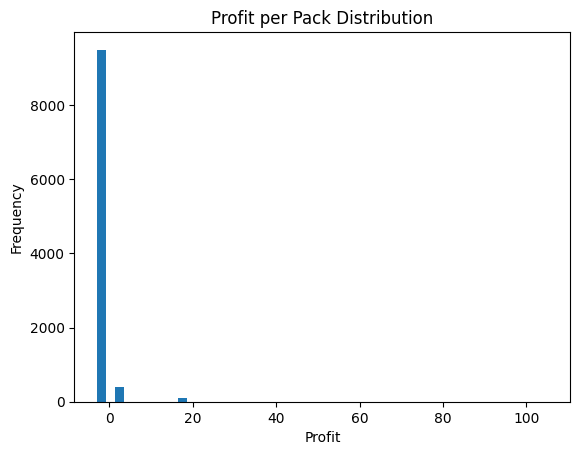

In [32]:
profits = [simulate_pack_value() - PACK_COST for _ in range(10000)]

plt.hist(profits, bins=50)
plt.title("Profit per Pack Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

In [33]:
prob_profit = sum(p > 0 for p in profits) / len(profits)
print("Probability of profit:", round(prob_profit, 3))

Probability of profit: 0.05


## Key Insight

While the expected value of opening Pokémon packs is negative, the distribution of outcomes is highly skewed.

A small number of high-value pulls creates the perception of profitability, even though most outcomes result in a loss.

This mirrors the behavior of lottery-style systems with asymmetric risk-reward profiles.